# Results Loader and Plots Comparison for all Models

In [ ]:
from pathlib import Path

import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_return_overlay, plot_test_overlay, plot_val_overlay
from src.utils import load_results_from_dir, results_to_df, set_seed

In [ ]:
cfg = Config.load()
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

OUT_DIR = Path(cfg.data.processed_dir)
FIG_DIR = Path(cfg.data.fig_dir)

In [ ]:
results = load_results_from_dir(OUT_DIR)
len(results), [r["kind"] for r in results]

In [ ]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

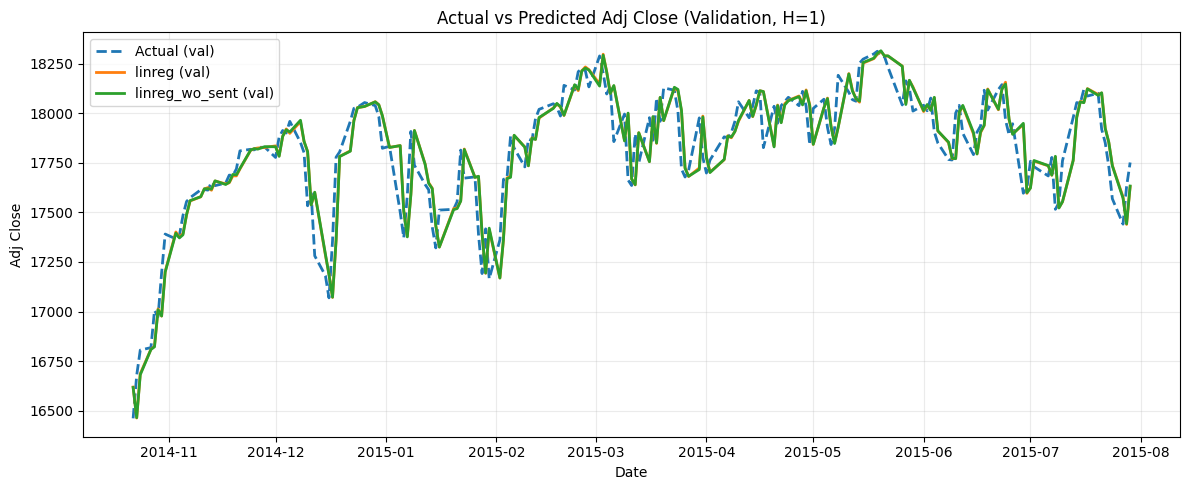

In [ ]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_val.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / "all_forecast.png")
plot_return_overlay(test, results, Path(cfg.data.fig_dir) / "all_returns.png", "test")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / "all_forecast_diagnostics.png")

In [ ]:
params_summary = results_to_df(results, "best_params")
params_summary

In [ ]:
metrics_summary = results_to_df(results, ["metrics", "test"])
metrics_summary